# EXPT 7 - Generate Synthetic Images using a GAN
**Name:** Jeevanantham K
**Roll No:** 24BAD047  
**Department:** AI & DS  
**Dataset:** MNIST Handwritten Digits

## PART A: Dataset Preparation and Image Preprocessing

Name: Jeevanantham K | Roll No: 24BAD047
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images shape : (60000, 28, 28)
Number of images      : 60000
Image dimensions      : (28, 28)
Pixel range (before)  : 0 to 255


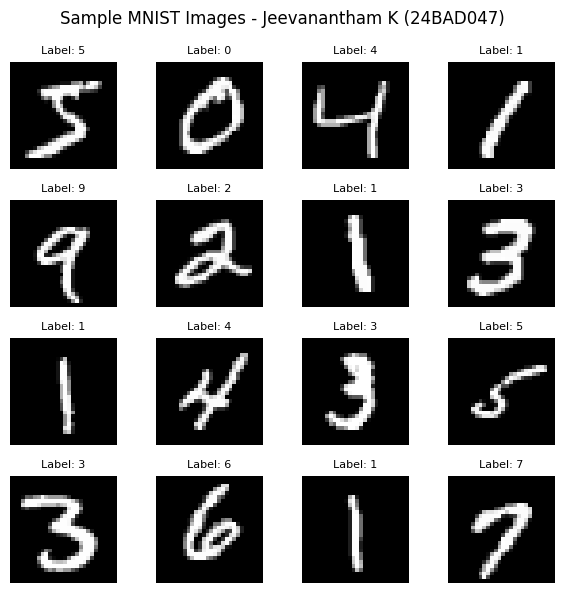

Shape after reshape   : (60000, 28, 28, 1)
Pixel range (after)   : -1.0 to 1.0
Number of batches per epoch: 468
Roll No: 24BAD047 - Part A completed


In [1]:
# importing the required libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers
import os, time

name = "Jeevanantham K"
roll_no = "24BAD047"
print("Name:", name, "| Roll No:", roll_no)

# loading the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# checking the number of images and image size
print("Training images shape :", x_train.shape)
print("Number of images      :", x_train.shape[0])
print("Image dimensions      :", x_train.shape[1:])
print("Pixel range (before)  :", x_train.min(), "to", x_train.max())

# displaying some sample images
plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title("Label: " + str(y_train[i]), fontsize=8)
    plt.axis("off")
plt.suptitle("Sample MNIST Images - " + name + " (" + roll_no + ")")
plt.tight_layout()
plt.show()

# normalizing pixel values to [-1, 1]
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5

# reshaping to (28, 28, 1) because the model needs a channel dimension
x_train = np.expand_dims(x_train, axis=-1)
print("Shape after reshape   :", x_train.shape)
print("Pixel range (after)   :", x_train.min(), "to", x_train.max())

# creating the batch-wise data pipeline
BUFFER_SIZE = 60000
BATCH_SIZE = 128
dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)
dataset = dataset.prefetch(tf.data.AUTOTUNE)
print("Number of batches per epoch:", len(dataset))
print("Roll No:", roll_no, "- Part A completed")

## PART B: Implementing the Generator

Name: Jeevanantham K | Roll No: 24BAD047


Model: "Generator_24BAD047"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,945 (8.89 MB)

 Trainable params: 2,305,473 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

Generated image shape: (1, 28, 28, 1)


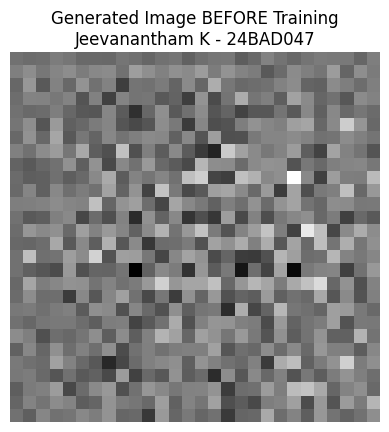

In [2]:
# size of the random noise vector given to the generator
LATENT_DIM = 100

def build_generator():
    model = tf.keras.Sequential(name="Generator_" + roll_no)
    model.add(layers.Input(shape=(LATENT_DIM,)))

    # dense layer to convert noise into a 7x7x256 feature map
    model.add(layers.Dense(7 * 7 * 256, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Reshape((7, 7, 256)))

    # transposed convolution layers to upsample the image
    model.add(layers.Conv2DTranspose(128, 5, strides=1, padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))

    model.add(layers.Conv2DTranspose(64, 5, strides=2, padding="same", use_bias=False))   # 14x14
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))

    # last layer uses tanh because the images are in [-1, 1]
    model.add(layers.Conv2DTranspose(1, 5, strides=2, padding="same", activation="tanh")) # 28x28
    return model

generator = build_generator()
print("Name:", name, "| Roll No:", roll_no)
generator.summary()

# generating one image from random noise before training
noise = tf.random.normal([1, LATENT_DIM])
untrained_img = generator(noise, training=False)
print("Generated image shape:", untrained_img.shape)

plt.imshow(untrained_img[0, :, :, 0], cmap="gray")
plt.title("Generated Image BEFORE Training\n" + name + " - " + roll_no)
plt.axis("off")
plt.show()

## PART C: Implementing the Discriminator and GAN Model

In [3]:
def build_discriminator():
    model = tf.keras.Sequential(name="Discriminator_" + roll_no)
    model.add(layers.Input(shape=(28, 28, 1)))

    # convolution layers to extract features from the image
    model.add(layers.Conv2D(64, 5, strides=2, padding="same"))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, 5, strides=2, padding="same"))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    # sigmoid output -> 1 = real image, 0 = fake image
    model.add(layers.Dense(1, activation="sigmoid"))
    return model

discriminator = build_discriminator()

# compiling the discriminator with Adam optimizer and binary cross-entropy loss
discriminator.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
                      loss="binary_crossentropy",
                      metrics=["accuracy"])

# freezing the discriminator inside the GAN, so only the generator is updated
discriminator.trainable = False

# combining generator and discriminator to make the GAN
gan = tf.keras.Sequential([generator, discriminator], name="GAN_" + roll_no)
gan.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
            loss="binary_crossentropy")

print("Name:", name, "| Roll No:", roll_no)
print("\n----- GENERATOR SUMMARY -----")
generator.summary()
print("\n----- DISCRIMINATOR SUMMARY -----")
discriminator.summary()
print("\n----- GAN SUMMARY -----")
gan.summary()

Name: Jeevanantham K | Roll No: 24BAD047

----- GENERATOR SUMMARY -----


Model: "Generator_24BAD047"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,945 (8.89 MB)

 Trainable params: 2,305,473 (8.79 MB)

...

Model: "GAN_24BAD047"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Generator_24BAD047 (Sequential) │ (None, 28, 28, 1)      │     2,330,945 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Discriminator_24BAD047          │ (None, 1)              │       212,865 │
│ (Sequential)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,543,810 (9.70 MB)

 Trainable params: 2,305,473 (8.79 MB)

 Non-trainable params: 238,337 (931.00 KB)

## PART D: GAN Training and Synthetic Image Generation

Name: Jeevanantham K | Roll No: 24BAD047
Training started...



/usr/local/lib/python3.13/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 01/50 | D Loss: 1.1042 | G Loss: 0.2679 | Time: 26.2s


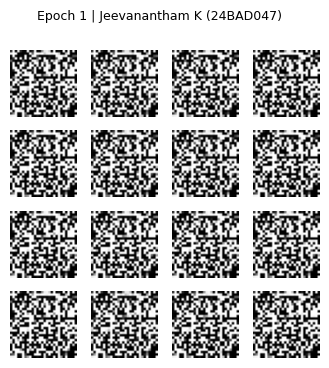

Epoch 02/50 | D Loss: 1.2572 | G Loss: 0.1794 | Time: 16.7s
Epoch 03/50 | D Loss: 1.2866 | G Loss: 0.1659 | Time: 17.3s
Epoch 04/50 | D Loss: 1.2995 | G Loss: 0.1601 | Time: 18.5s
Epoch 05/50 | D Loss: 1.3069 | G Loss: 0.1569 | Time: 17.6s
Epoch 06/50 | D Loss: 1.3116 | G Loss: 0.1548 | Time: 17.6s
Epoch 07/50 | D Loss: 1.3148 | G Loss: 0.1533 | Time: 18.0s
Epoch 08/50 | D Loss: 1.3173 | G Loss: 0.1522 | Time: 17.7s
Epoch 09/50 | D Loss: 1.3192 | G Loss: 0.1514 | Time: 17.3s
Epoch 10/50 | D Loss: 1.3207 | G Loss: 0.1507 | Time: 17.6s


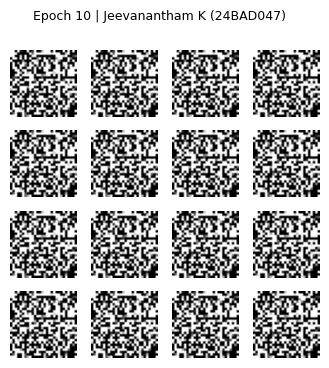

Epoch 11/50 | D Loss: 1.3220 | G Loss: 0.1502 | Time: 17.4s
Epoch 12/50 | D Loss: 1.3230 | G Loss: 0.1498 | Time: 17.9s
Epoch 13/50 | D Loss: 1.3238 | G Loss: 0.1494 | Time: 17.2s
Epoch 14/50 | D Loss: 1.3246 | G Loss: 0.1491 | Time: 17.3s
Epoch 15/50 | D Loss: 1.3253 | G Loss: 0.1488 | Time: 17.6s
Epoch 16/50 | D Loss: 1.3259 | G Loss: 0.1485 | Time: 17.4s
Epoch 17/50 | D Loss: 1.3264 | G Loss: 0.1483 | Time: 17.6s
Epoch 18/50 | D Loss: 1.3268 | G Loss: 0.1481 | Time: 17.4s
Epoch 19/50 | D Loss: 1.3273 | G Loss: 0.1479 | Time: 17.3s
Epoch 20/50 | D Loss: 1.3276 | G Loss: 0.1478 | Time: 17.7s


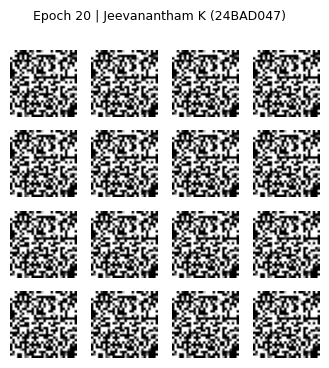

Epoch 21/50 | D Loss: 1.3279 | G Loss: 0.1476 | Time: 17.3s
Epoch 22/50 | D Loss: 1.3282 | G Loss: 0.1475 | Time: 17.7s
Epoch 23/50 | D Loss: 1.3285 | G Loss: 0.1474 | Time: 17.3s
Epoch 24/50 | D Loss: 1.3288 | G Loss: 0.1473 | Time: 17.4s
Epoch 25/50 | D Loss: 1.3290 | G Loss: 0.1472 | Time: 17.4s
Epoch 26/50 | D Loss: 1.3292 | G Loss: 0.1471 | Time: 17.2s
Epoch 27/50 | D Loss: 1.3294 | G Loss: 0.1470 | Time: 17.5s
Epoch 28/50 | D Loss: 1.3296 | G Loss: 0.1469 | Time: 17.2s
Epoch 29/50 | D Loss: 1.3298 | G Loss: 0.1469 | Time: 17.5s
Epoch 30/50 | D Loss: 1.3300 | G Loss: 0.1468 | Time: 17.5s


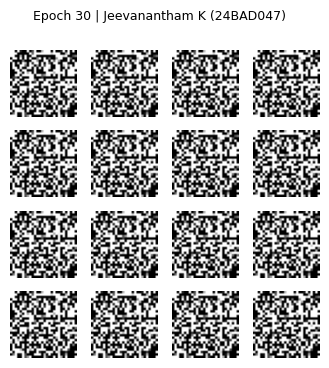

Epoch 31/50 | D Loss: 1.3301 | G Loss: 0.1467 | Time: 17.2s
Epoch 32/50 | D Loss: 1.3303 | G Loss: 0.1467 | Time: 17.6s
Epoch 33/50 | D Loss: 1.3304 | G Loss: 0.1466 | Time: 17.3s
Epoch 34/50 | D Loss: 1.3305 | G Loss: 0.1465 | Time: 17.4s
Epoch 35/50 | D Loss: 1.3307 | G Loss: 0.1465 | Time: 17.4s
Epoch 36/50 | D Loss: 1.3308 | G Loss: 0.1464 | Time: 17.2s
Epoch 37/50 | D Loss: 1.3309 | G Loss: 0.1464 | Time: 17.5s
Epoch 38/50 | D Loss: 1.3310 | G Loss: 0.1464 | Time: 17.2s
Epoch 39/50 | D Loss: 1.3311 | G Loss: 0.1463 | Time: 17.5s
Epoch 40/50 | D Loss: 1.3312 | G Loss: 0.1463 | Time: 17.4s


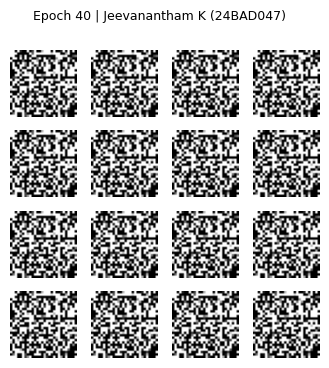

Epoch 41/50 | D Loss: 1.3313 | G Loss: 0.1462 | Time: 17.2s
Epoch 42/50 | D Loss: 1.3314 | G Loss: 0.1462 | Time: 17.6s
Epoch 43/50 | D Loss: 1.3315 | G Loss: 0.1462 | Time: 17.1s
Epoch 44/50 | D Loss: 1.3316 | G Loss: 0.1461 | Time: 17.4s
Epoch 45/50 | D Loss: 1.3316 | G Loss: 0.1461 | Time: 17.3s
Epoch 46/50 | D Loss: 1.3317 | G Loss: 0.1461 | Time: 17.2s
Epoch 47/50 | D Loss: 1.3318 | G Loss: 0.1460 | Time: 17.6s
Epoch 48/50 | D Loss: 1.3318 | G Loss: 0.1460 | Time: 17.3s
Epoch 49/50 | D Loss: 1.3319 | G Loss: 0.1460 | Time: 17.5s
Epoch 50/50 | D Loss: 1.3320 | G Loss: 0.1460 | Time: 17.4s


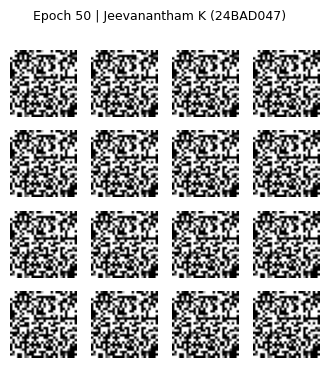


Training completed


In [4]:
EPOCHS = 50
SAVE_EVERY = 10

# folder to save the generated images
os.makedirs("generated_images", exist_ok=True)

# fixed noise, so we can see how the same noise improves over epochs
seed = tf.random.normal([16, LATENT_DIM])

# function to display and save a grid of generated images
def show_and_save(images, epoch):
    images = (images + 1) / 2.0     # converting back from [-1,1] to [0,1]
    plt.figure(figsize=(4, 4))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i, :, :, 0], cmap="gray")
        plt.axis("off")
    plt.suptitle("Epoch " + str(epoch) + " | " + name + " (" + roll_no + ")", fontsize=9)
    plt.savefig("generated_images/epoch_" + str(epoch) + "_" + roll_no + ".png", dpi=150)
    plt.show()

d_loss_list = []
g_loss_list = []

print("Name:", name, "| Roll No:", roll_no)
print("Training started...\n")

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    d_losses = []
    g_losses = []

    for real_images in dataset:
        batch_size = real_images.shape[0]

        # ---------- training the discriminator ----------
        noise = tf.random.normal([batch_size, LATENT_DIM])
        fake_images = generator(noise, training=True)

        real_labels = tf.ones((batch_size, 1)) * 0.9   # label smoothing
        fake_labels = tf.zeros((batch_size, 1))

        d_loss_real = discriminator.train_on_batch(real_images, real_labels)[0]
        d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels)[0]
        d_loss = 0.5 * (d_loss_real + d_loss_fake)

        # ---------- training the generator through the GAN ----------
        noise = tf.random.normal([batch_size, LATENT_DIM])
        g_loss = gan.train_on_batch(noise, tf.ones((batch_size, 1)))

        d_losses.append(d_loss)
        g_losses.append(g_loss)

    # average loss of this epoch
    d_loss_list.append(np.mean(d_losses))
    g_loss_list.append(np.mean(g_losses))
    print("Epoch %02d/%d | D Loss: %.4f | G Loss: %.4f | Time: %.1fs" %
          (epoch, EPOCHS, d_loss_list[-1], g_loss_list[-1], time.time() - start))

    # generating images at regular intervals
    if epoch == 1 or epoch % SAVE_EVERY == 0:
        show_and_save(generator(seed, training=False).numpy(), epoch)

print("\nTraining completed")

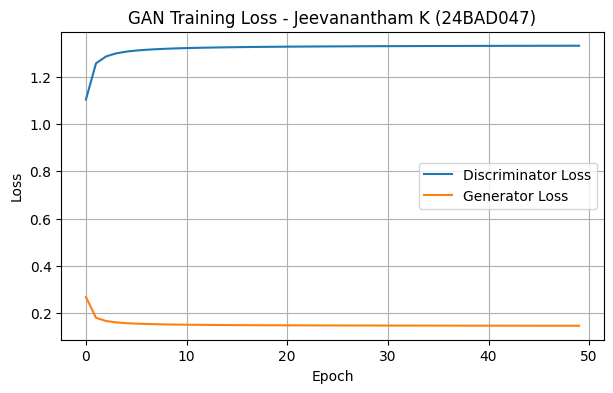

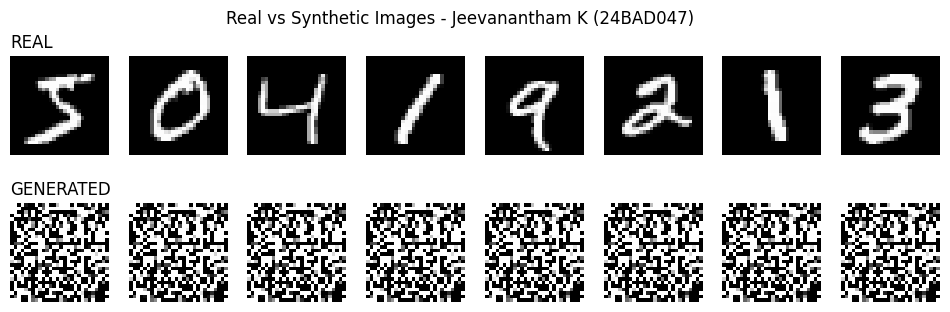

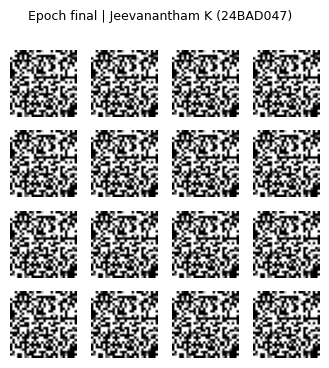

Final images saved in generated_images folder | Roll No: 24BAD047


In [5]:
# plotting generator and discriminator loss
plt.figure(figsize=(7, 4))
plt.plot(d_loss_list, label="Discriminator Loss")
plt.plot(g_loss_list, label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss - " + name + " (" + roll_no + ")")
plt.legend()
plt.grid(True)
plt.savefig("generated_images/loss_curve_" + roll_no + ".png", dpi=150)
plt.show()

# comparing real images (top row) with generated images (bottom row)
fake_samples = generator(tf.random.normal([8, LATENT_DIM]), training=False).numpy()
fake_samples = (fake_samples + 1) / 2
real_samples = (x_train[:8] + 1) / 2

fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for i in range(8):
    axes[0, i].imshow(real_samples[i, :, :, 0], cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(fake_samples[i, :, :, 0], cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_title("REAL", loc="left")
axes[1, 0].set_title("GENERATED", loc="left")
plt.suptitle("Real vs Synthetic Images - " + name + " (" + roll_no + ")")
plt.savefig("generated_images/real_vs_fake_" + roll_no + ".png", dpi=150)
plt.show()

# saving the final generated images and the generator model
show_and_save(generator(seed, training=False).numpy(), "final")
generator.save("generator_" + roll_no + ".keras")
print("Final images saved in generated_images folder | Roll No:", roll_no)